## Import data

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
orders = pd.read_csv('final_clean_df.csv')
orders.head()

,customer_id,order_id,product_code,product_name,quantity,unit_price,purchase_date,line_total,is_gift,is_subproduct,...,avg_consumption_days,consumption_bucket,price_tier,total_orders,total_products_bought,total_spend_tl,tenure_bucket,est_returns,has_returned,missing_product_info
0,T24540,TS010135579,362,Clinique For Men Kırışık Karşıtı Göz Kremi 15 Ml,1,756.0,2024-01-01,756.0,False,False,...,60,quarterly,Luxury,1.0,5.0,1984.41,2_to_3yr,0.0,False,False
1,T24667,TS010135506,1212,Lancome Hypnose Kadın Parfüm Edp 75 Ml,1,2990.0,2024-01-01,2990.0,False,False,...,180,biannual,Luxury,1.0,1.0,2990.00,2_to_3yr,0.0,False,False
2,T24668,TS010135510,1970,Carolina Herrera 212 Sexy Men Erkek Parfüm Edt...,1,2449.6,2024-01-01,2449.6,False,False,...,180,biannual,Luxury,3.0,3.0,9788.10,2_to_3yr,0.0,False,False
3,ts_1704131707_8429,TS010135585,1970,Carolina Herrera 212 Sexy Men Erkek Parfüm Edt...,1,2449.6,2024-01-01,2449.6,False,False,...,180,biannual,Luxury,NaN,NaN,NaN,NaN,NaN,NaN,False
4,T1186,TS010135548,3480,YSL La Nuit De L'Homme Erkek Deo Stick 75 Gr,1,916.5,2024-01-01,916.5,False,False,...,45,quarterly,Luxury,184.0,1433.0,1503396.85,>3yr,0.0,False,False


In [ ]:
n_users = orders['customer_id'].nunique()
print("Unique users:", n_users)

Unique users: 32663


In [ ]:
orders = orders.loc[orders['is_member']==1]
orders.head()

,customer_id,order_id,product_code,product_name,quantity,unit_price,purchase_date,line_total,is_gift,is_subproduct,...,avg_consumption_days,consumption_bucket,price_tier,total_orders,total_products_bought,total_spend_tl,tenure_bucket,est_returns,has_returned,missing_product_info
0,T24540,TS010135579,362,Clinique For Men Kırışık Karşıtı Göz Kremi 15 Ml,1,756.0,2024-01-01,756.0,False,False,...,60,quarterly,Luxury,1.0,5.0,1984.41,2_to_3yr,0.0,False,False
1,T24667,TS010135506,1212,Lancome Hypnose Kadın Parfüm Edp 75 Ml,1,2990.0,2024-01-01,2990.0,False,False,...,180,biannual,Luxury,1.0,1.0,2990.00,2_to_3yr,0.0,False,False
2,T24668,TS010135510,1970,Carolina Herrera 212 Sexy Men Erkek Parfüm Edt...,1,2449.6,2024-01-01,2449.6,False,False,...,180,biannual,Luxury,3.0,3.0,9788.10,2_to_3yr,0.0,False,False
4,T1186,TS010135548,3480,YSL La Nuit De L'Homme Erkek Deo Stick 75 Gr,1,916.5,2024-01-01,916.5,False,False,...,45,quarterly,Luxury,184.0,1433.0,1503396.85,>3yr,0.0,False,False
5,T8144,TS010135552,4633,Giorgio Armani Code Femme Kadın Parfüm Edp 75 Ml,1,2996.5,2024-01-01,2996.5,False,False,...,180,biannual,Luxury,5.0,8.0,26584.03,>3yr,0.0,False,False


In [ ]:
one_order_users = (orders_per_user == 1).sum()
multi_order_users = (orders_per_user > 1).sum()

print("Users with 1 order:", one_order_users)
print("Users with >1 order:", multi_order_users)
print("% single-order users:", one_order_users / len(orders_per_user))

Users with 1 order: 13899
Users with >1 order: 5253
% single-order users: 0.7257205513784462


In [ ]:
#there were some issues with memory due to size so had to use the following library

from scipy.sparse import csr_matrix

USER_COL = "customer_id"
ITEM_COL = "product_name"
QTY_COL  = "quantity"

ui = (
    orders
    .groupby([USER_COL, ITEM_COL])[QTY_COL]
    .sum()
    .reset_index()
)

# Apply log transform
ui["weight"] = np.log1p(ui[QTY_COL])   # log(quantity + 1)

# Factorize IDs
user_codes, user_index = pd.factorize(ui[USER_COL])
item_codes, item_index = pd.factorize(ui[ITEM_COL])

# Build sparse matrix with weights
X_ui = csr_matrix(
    (ui["weight"].astype(np.float32), (user_codes, item_codes)),
    shape=(len(user_index), len(item_index))
)

# Optional: sparse dataframe wrapper
user_item_df = pd.DataFrame.sparse.from_spmatrix(
    X_ui,
    index=user_index,
    columns=item_index
)

user_item_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19152 entries, T10002 to T9996
Columns: 9622 entries, Jean Paul Gaultier Le Male Ekrek Deo Stick 75 Gr to Jagler Sport for Men Erkek Deodorant 150 Ml
dtypes: Sparse[float32, 0](9622)
memory usage: 609.7+ KB


In [ ]:
user_item_df.head()

,Jean Paul Gaultier Le Male Ekrek Deo Stick 75 Gr,Jean Paul Gaultier Le Male Erkek Deodorant 150 Ml,Elidor Belirgin Bukleler 7/24 Bakım Kremi 240 Ml,Flormar Nail Enamel Oje 128 Bordeaux Scream,Flormar Nail Enamel Oje 228 Bordeaux Red,Flormar Nail Enamel Oje 306 Lost in Bordeaux,Flormar Nail Enamel Oje 310 Snow White,Flormar Nail Enamel Oje 313 Black Minimalism,Flormar Nail Enamel Oje 323 Cherry Desert,Flormar Nail Enamel Oje 416 Straight Red,...,Clinique Even Better Clinical Foundation CN 02 Breeze,Guerlain Parure Gold 23 Skin Control Compact Foundation 2N,Guerlain Parure Gold 23 Skin Control Compact Foundation 3N,Guerlain Parure Gold Foundation Skin Matte 2W,Biomagic Saç Boyası 66.43,Dior Diorshow Mono Couleur Couture Eyeshadow 481 Poncho,Shiseido Synchro Self Refreshing Foundation 240,YSL La Vestiaire Lavalliere Unisex Parfüm Edp 125 Ml,YSL Lines Liberated Eyeliner 11,Jagler Sport for Men Erkek Deodorant 150 Ml
T10002,0.693147,0.693147,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
T10008,0,0,1.098612,1.791759,1.94591,1.94591,1.94591,1.94591,1.94591,1.94591,...,0,0,0,0,0,0,0,0,0,0
T1002,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
T10060,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
T10061,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


**Collaborative Filtering using KNN**

In [ ]:
# =========================
# Item-based kNN Collaborative Filtering (Cosine)
# - Builds sparse user-item matrix (binary)
# - Leave-one-out split
# - Fits NearestNeighbors on item vectors
# - Recommends per user
# - Evaluates HitRate@K and MRR@K
# =========================

from sklearn.neighbors import NearestNeighbors

# -------------------------
# 0) Build X_ui (users × items) from orders
# -------------------------

user_to_row = {u: i for i, u in enumerate(user_index)}
item_names = np.array(item_index)

print("X_ui shape (users, items):", X_ui.shape, "| nnz:", X_ui.nnz)

# -------------------------
# 1) Leave-one-out train/test split
# -------------------------
def train_test_split_leave_one_out(X_ui: csr_matrix, seed: int = 42):
    rng = np.random.default_rng(seed)
    X = X_ui.tocsr()

    n_users = X.shape[0]
    test_item_by_user = -np.ones(n_users, dtype=np.int32)
    eval_users = []

    X_train = X.copy().tolil()
    for u in range(n_users):
        items = X[u].indices
        if len(items) >= 2:
            t = int(rng.choice(items))
            test_item_by_user[u] = t
            eval_users.append(u)
            X_train[u, t] = 0

    X_train = X_train.tocsr()
    X_train.eliminate_zeros()
    return X_train, test_item_by_user, np.array(eval_users, dtype=np.int32)

X_train, test_item_by_user, eval_users = train_test_split_leave_one_out(X_ui, seed=42)
print("X_train nnz:", X_train.nnz, "| eval_users:", len(eval_users))

# -------------------------
# 2) Fit item-based kNN on TRAIN data (items × users)
# -------------------------
X_iu_train = X_train.T.tocsr()  # items × users

K_NEIGHBORS = 200  # neighbors to consider per seed item (100–300 common)
knn = NearestNeighbors(metric="cosine", algorithm="brute", n_neighbors=K_NEIGHBORS + 1, n_jobs=-1)
knn.fit(X_iu_train)

# -------------------------
# 3) Recommend for a user (row index)
#    Score candidate items by sum(similarity) over items the user already has
# -------------------------
def recommend_knn_user(u: int,
                       X_train: csr_matrix,
                       X_iu_train: csr_matrix,
                       knn: NearestNeighbors,
                       topn: int = 10,
                       k_neighbors: int = 200):
    user_items = X_train[u].indices
    if len(user_items) == 0:
        return pd.DataFrame(columns=["product", "score"])

    user_item_set = set(user_items.tolist())
    scores = {}

    for j in user_items:
        dists, nbrs = knn.kneighbors(X_iu_train[j], n_neighbors=k_neighbors + 1)
        dists = dists.ravel()[1:]  # drop itself
        nbrs  = nbrs.ravel()[1:]
        sims = 1.0 - dists

        for nb, s in zip(nbrs, sims):
            if nb in user_item_set:
                continue
            scores[nb] = scores.get(nb, 0.0) + float(s)

    if not scores:
        return pd.DataFrame(columns=["product", "score"])

    items = np.fromiter(scores.keys(), dtype=np.int32)
    sc    = np.fromiter(scores.values(), dtype=np.float32)

    top_idx = np.argpartition(-sc, topn)[:topn]
    top_idx = top_idx[np.argsort(-sc[top_idx])]

    return pd.DataFrame({
        "product": item_names[items[top_idx]],
        "score": sc[top_idx]
    })

def recommend_knn(customer_id, topn: int = 10):
    if customer_id not in user_to_row:
        return pd.DataFrame(columns=["product", "score"])
    u = int(user_to_row[customer_id])
    return recommend_knn_user(u, X_train, X_iu_train, knn, topn=topn, k_neighbors=K_NEIGHBORS)

# Example:
# recommend_knn(user_index[0], topn=10)

# -------------------------
# 4) Evaluation: HitRate@K and MRR@K (leave-one-out)
# -------------------------
def eval_knn(X_train: csr_matrix,
             test_item_by_user: np.ndarray,
             eval_users: np.ndarray,
             X_iu_train: csr_matrix,
             knn: NearestNeighbors,
             K: int = 20,
             k_neighbors: int = 200):

    hits = 0
    mrr = 0.0
    n = 0

    for u in eval_users:
        t = int(test_item_by_user[u])
        if t < 0:
            continue

        rec = recommend_knn_user(
            u, X_train, X_iu_train, knn, topn=K, k_neighbors=k_neighbors
        )

        n += 1
        if rec.empty:
            continue

        rec_items = rec["product"].to_numpy()
        # map recommended product names back to item indices for rank check
        # (faster: keep indices in recommend_knn_user; this is simple and readable)
        # We'll do rank based on names by comparing to item_names[t]
        target_name = item_names[t]
        where = np.where(rec_items == target_name)[0]
        if where.size:
            hits += 1
            mrr += 1.0 / (int(where[0]) + 1)

    return {
        "K": K,
        "users_evaluated": n,
        "hit_rate@K": hits / n if n else 0.0,
        "mrr@K": mrr / n if n else 0.0
    }

metrics_knn = eval_knn(X_train, test_item_by_user, eval_users, X_iu_train, knn, K=20, k_neighbors=K_NEIGHBORS)
print(metrics_knn)

X_ui shape (users, items): (19152, 9622) | nnz: 58885
X_train nnz: 49558 | eval_users: 9327
{'K': 20, 'users_evaluated': 9327, 'hit_rate@K': 0.08459311675779993, 'mrr@K': 0.030779083227881063}


**Colaborative Filtering: Truncated SVD**

In [ ]:
# =========================
# Truncated SVD Recommender
# - No TF-IDF weighting
# - Uses Pipeline + Normalizer
# - Includes leave-one-out split, recommend(), and evaluation (HitRate@K, MRR@K)
# =========================

from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.pipeline import make_pipeline

# -------------------------
# 0) Build X_ui (users × items) from orders
# -------------------------

user_to_row = {u: i for i, u in enumerate(user_index)}
item_names = np.array(item_index)

print("X_ui shape (users, items):", X_ui.shape, "| nnz:", X_ui.nnz)

# -------------------------
# 1) Leave-one-out train/test split
#    (only evaluates users with >=2 interacted items)
# -------------------------
def train_test_split_leave_one_out(X_ui: csr_matrix, seed: int = 42):
    rng = np.random.default_rng(seed)
    X = X_ui.tocsr()

    n_users = X.shape[0]
    test_item_by_user = -np.ones(n_users, dtype=np.int32)
    eval_users = []

    X_train = X.copy().tolil()
    for u in range(n_users):
        items = X[u].indices
        if len(items) >= 2:
            t = int(rng.choice(items))
            test_item_by_user[u] = t
            eval_users.append(u)
            X_train[u, t] = 0

    X_train = X_train.tocsr()
    X_train.eliminate_zeros()
    return X_train, test_item_by_user, np.array(eval_users, dtype=np.int32)

X_train, test_item_by_user, eval_users = train_test_split_leave_one_out(X_ui, seed=42)
print("X_train nnz:", X_train.nnz, "| eval_users:", len(eval_users))

# -------------------------
# 2) Fit TruncatedSVD + Normalizer pipeline
# -------------------------
n_factors = 50
svd = TruncatedSVD(n_components=n_factors, random_state=42)
svd_model = make_pipeline(svd, Normalizer(copy=False))

# Use float32 to reduce memory; X_train is sparse (users × items)
X_train_w = X_train.astype(np.float32)

U = svd_model.fit_transform(X_train_w)                        # users × k
Vt = svd_model.named_steps["truncatedsvd"].components_        # k × items

print("U shape:", U.shape, "| Vt shape:", Vt.shape)

# -------------------------
# 3) Recommendation functions
# -------------------------
def recommend_svd_user(u: int, X_train: csr_matrix, U: np.ndarray, Vt: np.ndarray, topn: int = 10):
    # scores for all items
    scores = U[u].dot(Vt)  # (n_items,)

    # filter already-seen items
    seen = X_train[u].indices
    scores[seen] = -np.inf

    # top-n efficiently
    top_idx = np.argpartition(-scores, topn)[:topn]
    top_idx = top_idx[np.argsort(-scores[top_idx])]

    return pd.DataFrame({
        "product": item_names[top_idx],
        "score": scores[top_idx]
    })

def recommend_svd(customer_id, topn: int = 10):
    if customer_id not in user_to_row:
        return pd.DataFrame(columns=["product", "score"])
    u = int(user_to_row[customer_id])
    return recommend_svd_user(u, X_train, U, Vt, topn=topn)

# Example:
# recommend_svd(user_index[0], topn=10)

# -------------------------
# 4) Evaluation: HitRate@K and MRR@K (leave-one-out)
# -------------------------
def eval_svd(X_train: csr_matrix,
             test_item_by_user: np.ndarray,
             eval_users: np.ndarray,
             U: np.ndarray,
             Vt: np.ndarray,
             K: int = 20):
    hits = 0
    mrr = 0.0
    n = 0

    for u in eval_users:
        t = int(test_item_by_user[u])
        if t < 0:
            continue

        scores = U[u].dot(Vt)
        scores[X_train[u].indices] = -np.inf

        top_idx = np.argpartition(-scores, K)[:K]
        top_idx = top_idx[np.argsort(-scores[top_idx])]

        n += 1
        where = np.where(top_idx == t)[0]
        if where.size:
            hits += 1
            mrr += 1.0 / (int(where[0]) + 1)

    return {
        "K": K,
        "users_evaluated": n,
        "hit_rate@K": hits / n if n else 0.0,
        "mrr@K": mrr / n if n else 0.0
    }

metrics_svd = eval_svd(X_train, test_item_by_user, eval_users, U, Vt, K=20)
print(metrics_svd)

X_ui shape (users, items): (19152, 9622) | nnz: 58885
X_train nnz: 49558 | eval_users: 9327
U shape: (19152, 270) | Vt shape: (270, 9622)
{'K': 20, 'users_evaluated': 9327, 'hit_rate@K': 0.11622172188270612, 'mrr@K': 0.04531034066702501}


**Model Comparisons**

In [ ]:
comparison = pd.DataFrame([
    {
        "Model": "Item-based CF (kNN)",
        "HitRate@20": metrics_knn["hit_rate@K"],
        "MRR@20": metrics_knn["mrr@K"],
        "Users Evaluated": metrics_knn["users_evaluated"]
    },
    {
        "Model": "Truncated SVD",
        "HitRate@20": metrics_svd["hit_rate@K"],
        "MRR@20": metrics_svd["mrr@K"],
        "Users Evaluated": metrics_svd["users_evaluated"]
    },
])

comparison = comparison.sort_values("HitRate@20", ascending=False)

comparison

,Model,HitRate@20,MRR@20,Users Evaluated
1,Truncated SVD,0.116222,0.045310,9327
0,Item-based CF (kNN),0.084593,0.030779,9327


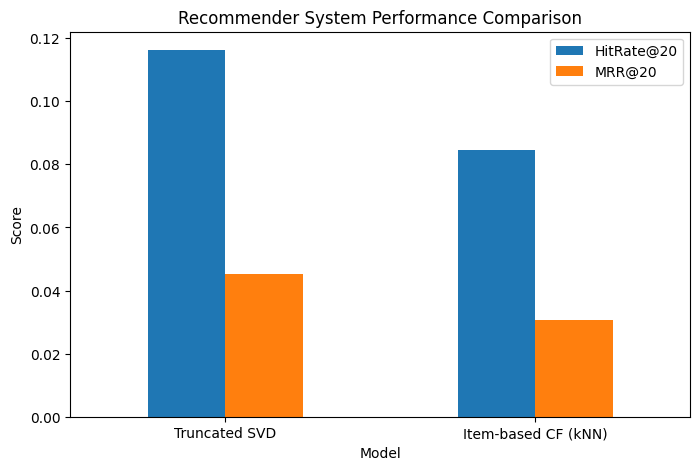

In [ ]:
import matplotlib.pyplot as plt

comparison.set_index("Model")[["HitRate@20","MRR@20"]].plot.bar(figsize=(8,5))
plt.title("Recommender System Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()